# Chapter 6 (6.1–6.4): Data Engineering & ETL Pipelines
This notebook covers:

- **6.1** Overview of data engineering in applied data science
- **6.2** Designing and implementing ETL pipelines
- **6.3** Automating workflows with schedulers
- **6.4** Logging, monitoring, and error handling

> **Goal:** Build reliable, automated data pipelines that extract, transform, and load data with proper monitoring.

## Setup

In [1]:
import numpy as np
import pandas as pd
import json
import logging
import time
import os
from datetime import datetime, timedelta
from functools import wraps
from typing import Callable, Any

np.random.seed(42)

---
## 6.1 Overview of Data Engineering in Applied Data Science

### What is Data Engineering?

Data Engineering is the practice of designing and building systems for collecting, storing, and analyzing data at scale.

| Role | Focus | Key Skills |
|------|-------|------------|
| **Data Scientist** | Analysis, modeling, insights | Statistics, ML, visualization |
| **Data Engineer** | Data infrastructure, pipelines | ETL, databases, orchestration |
| **Data Analyst** | Reporting, business intelligence | SQL, dashboards, Excel |

### Why Data Engineering Matters for Data Science

- **Data Quality**: Garbage in, garbage out → clean pipelines = better models
- **Scalability**: Handle growing data volumes without manual work
- **Reproducibility**: Same pipeline, same results every time
- **Automation**: Free up time for analysis, not data wrangling

### The Data Engineering Lifecycle

```
┌─────────┐    ┌───────────┐    ┌────────┐    ┌─────────┐    ┌──────────┐
│ Sources │───▶│  Extract  │───▶│Transform│───▶│  Load   │───▶│  Serve   │
└─────────┘    └───────────┘    └────────┘    └─────────┘    └──────────┘
   APIs           Ingest          Clean          Store         Analytics
   Files          Validate        Enrich         Database      Reports
   DBs            Schedule        Aggregate      Warehouse     ML Models
```

### Quick Demo: Before vs After Data Engineering

In [2]:
# BEFORE: Manual, error-prone process
print("=== BEFORE: Manual Data Processing ===")
print("1. Download CSV from email")
print("2. Open in Excel, manually fix dates")
print("3. Copy-paste into another sheet")
print("4. Create pivot table")
print("5. Email results to stakeholders")
print("\n⚠️ Problems: Time-consuming, inconsistent, not reproducible")

=== BEFORE: Manual Data Processing ===
1. Download CSV from email
2. Open in Excel, manually fix dates
3. Copy-paste into another sheet
4. Create pivot table
5. Email results to stakeholders

⚠️ Problems: Time-consuming, inconsistent, not reproducible


In [3]:
# AFTER: Automated, reliable pipeline
print("=== AFTER: Automated Pipeline ===")
print("1. Scheduler triggers pipeline at 6 AM")
print("2. Extract data from source automatically")
print("3. Transform with validated rules")
print("4. Load to data warehouse")
print("5. Dashboard updates automatically")
print("\n✓ Benefits: Fast, consistent, scalable, auditable")

=== AFTER: Automated Pipeline ===
1. Scheduler triggers pipeline at 6 AM
2. Extract data from source automatically
3. Transform with validated rules
4. Load to data warehouse
5. Dashboard updates automatically

✓ Benefits: Fast, consistent, scalable, auditable


**Discuss:**
- What data tasks do you currently do manually that could be automated?
- What happens when the person who does the manual process is on vacation?

---
## 6.2 Designing and Implementing ETL Pipelines

### What is ETL?

| Step | Description | Example |
|------|-------------|---------|
| **E**xtract | Get data from sources | Read CSV, call API, query database |
| **T**ransform | Clean and reshape data | Remove nulls, convert types, join tables |
| **L**oad | Store processed data | Write to database, save to file |

### 6.2.1 Simple ETL Example

In [6]:
# EXTRACT: Create sample raw data (simulating a messy source)
raw_data = {
    "name": ["Alice", "Bob", "CHARLIE", "diana", None],
    "age": [25, 30, None, 28, 22],
    "salary": ["50000", "60000", "55000", "invalid", "45000"],
    "hire_date": ["2023-01-15", "2022-06-20", "2024-03-10", "2023-11-25", "2024-01-05"]
}
df_raw = pd.DataFrame(raw_data)
print("=== RAW DATA (Extract) ===")
print(df_raw)
print(f"\nData types:\n{df_raw.dtypes}")

=== RAW DATA (Extract) ===
      name   age   salary   hire_date
0    Alice  25.0    50000  2023-01-15
1      Bob  30.0    60000  2022-06-20
2  CHARLIE   NaN    55000  2024-03-10
3    diana  28.0  invalid  2023-11-25
4     None  22.0    45000  2024-01-05

Data types:
name          object
age          float64
salary        object
hire_date     object
dtype: object


In [7]:
# TRANSFORM: Clean and standardize
df_clean = df_raw.copy()

# 1. Standardize names (title case)
df_clean["name"] = df_clean["name"].str.title()

# 2. Handle missing values
df_clean["name"] = df_clean["name"].fillna("Unknown")
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# 3. Convert salary to numeric (handle errors)
df_clean["salary"] = pd.to_numeric(df_clean["salary"], errors="coerce")
df_clean["salary"] = df_clean["salary"].fillna(df_clean["salary"].median())

# 4. Convert date strings to datetime
df_clean["hire_date"] = pd.to_datetime(df_clean["hire_date"])

# 5. Add derived column
df_clean["years_employed"] = ((pd.Timestamp.now() - df_clean["hire_date"]).dt.days / 365).round(1)

print("=== CLEAN DATA (Transform) ===")
print(df_clean)
print(f"\nData types:\n{df_clean.dtypes}")

=== CLEAN DATA (Transform) ===
      name   age   salary  hire_date  years_employed
0    Alice  25.0  50000.0 2023-01-15             3.1
1      Bob  30.0  60000.0 2022-06-20             3.7
2  Charlie  26.5  55000.0 2024-03-10             1.9
3    Diana  28.0  52500.0 2023-11-25             2.2
4  Unknown  22.0  45000.0 2024-01-05             2.1

Data types:
name                      object
age                      float64
salary                   float64
hire_date         datetime64[ns]
years_employed           float64
dtype: object


#### What `errors="coerce"` Does in `pd.to_numeric()`

The `errors` parameter controls how pandas handles values that **cannot be converted** to numbers:

| Option | Behavior | Result for Invalid Values |
|--------|----------|---------------------------|
| `"raise"` (default) | Throws an error | ValueError exception |
| `"coerce"` | Forces conversion | Converts to `NaN` |
| `"ignore"` | Skips conversion | Returns original value |
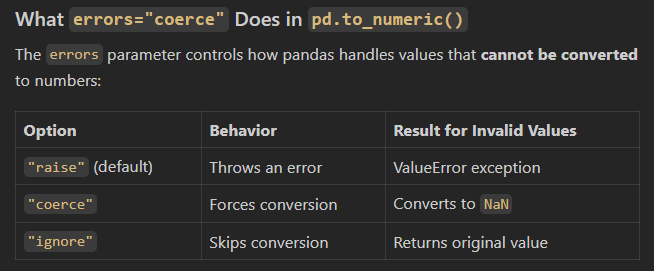

In [8]:
# LOAD: Save to file (could also be database, API, etc.)
output_path = "employees_clean.csv"
df_clean.to_csv(output_path, index=False)
print(f"=== LOADED to {output_path} ===")
print(f"Rows: {len(df_clean)}, Columns: {len(df_clean.columns)}")

=== LOADED to employees_clean.csv ===
Rows: 5, Columns: 5


**Try:**
1. What happens if you don't use `errors="coerce"` in `pd.to_numeric()`?
2. Change the fill strategy for `age` from median to mean. Which is more robust?
3. Add another derived column: `salary_monthly = salary / 12`

### 6.2.2 Modular ETL with Functions

In [9]:
# Each step is a pure function: input → output

def extract_sales_data() -> pd.DataFrame:
    """Extract raw sales data from source."""
    data = {
        "date": pd.date_range("2024-01-01", periods=50, freq="D"),
        "product": np.random.choice(["Laptop", "Mouse", "Keyboard"], 50),
        "quantity": np.random.randint(1, 20, 50),
        "unit_price": np.random.choice([999.99, 29.99, 79.99], 50),
        "region": np.random.choice(["North", "South", "East", "West"], 50)
    }
    df = pd.DataFrame(data)
    # Add some messiness
    df.loc[5:7, "quantity"] = np.nan
    df.loc[10, "unit_price"] = -99.99  # Invalid price
    return df

def transform_clean(df: pd.DataFrame) -> pd.DataFrame:
    """Clean data: handle nulls and invalid values."""
    df = df.copy()
    df["quantity"] = df["quantity"].fillna(df["quantity"].median())
    df = df[df["unit_price"] > 0]  # Remove invalid prices
    return df

def transform_enrich(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived columns."""
    df = df.copy()
    df["revenue"] = df["quantity"] * df["unit_price"]
    df["month"] = df["date"].dt.to_period("M")
    df["day_of_week"] = df["date"].dt.day_name()
    return df

def transform_aggregate(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate by product and region."""
    return df.groupby(["product", "region"]).agg({
        "revenue": "sum",
        "quantity": "sum"
    }).reset_index()

def load_to_csv(df: pd.DataFrame, filepath: str) -> None:
    """Save DataFrame to CSV."""
    df.to_csv(filepath, index=False)
    print(f"Saved {len(df)} rows to {filepath}")

In [10]:
# Run the modular pipeline
raw = extract_sales_data()
print(f"Extracted: {len(raw)} rows")

clean = transform_clean(raw)
print(f"After cleaning: {len(clean)} rows")

enriched = transform_enrich(clean)
print(f"After enrichment: {len(enriched)} rows, {len(enriched.columns)} columns")

aggregated = transform_aggregate(enriched)
print(f"After aggregation: {len(aggregated)} rows")

load_to_csv(aggregated, "sales_summary.csv")

Extracted: 50 rows
After cleaning: 49 rows
After enrichment: 49 rows, 8 columns
After aggregation: 12 rows
Saved 12 rows to sales_summary.csv


### 6.2.3 ETL Pipeline as a Class

In [11]:
class DataPipeline:
    """
    A configurable data pipeline that chains transformation steps.
    """
    
    def __init__(self, name: str):
        self.name = name
        self.steps = []
        self.data = None
    
    def add_step(self, func: Callable, name: str = None):
        """Add a transformation step to the pipeline."""
        step_name = name or func.__name__
        self.steps.append((step_name, func))
        return self  # Enable method chaining
    
    def run(self, initial_data: pd.DataFrame = None) -> pd.DataFrame:
        """Execute all pipeline steps in order."""
        print(f"\n{'='*50}")
        print(f"Running Pipeline: {self.name}")
        print(f"{'='*50}")
        
        self.data = initial_data
        
        for step_name, func in self.steps:
            print(f"\n→ Executing: {step_name}")
            start = time.time()
            
            if self.data is None:
                self.data = func()  # Extract step
            else:
                self.data = func(self.data)  # Transform step
            
            elapsed = time.time() - start
            
            if isinstance(self.data, pd.DataFrame):
                print(f"  ✓ Completed in {elapsed:.3f}s | Rows: {len(self.data)}")
            else:
                print(f"  ✓ Completed in {elapsed:.3f}s")
        
        print(f"\n{'='*50}")
        print(f"Pipeline Complete: {self.name}")
        print(f"{'='*50}\n")
        
        return self.data

In [13]:
# Create and run pipeline using the class
pipeline = DataPipeline("Sales ETL")

pipeline.add_step(extract_sales_data, "Extract Sales Data")
pipeline.add_step(transform_clean, "Clean Data")
pipeline.add_step(transform_enrich, "Enrich with Derived Columns")
pipeline.add_step(transform_aggregate, "Aggregate by Product & Region")

result = pipeline.run()
print(result.head())


Running Pipeline: Sales ETL

→ Executing: Extract Sales Data
  ✓ Completed in 0.003s | Rows: 50

→ Executing: Clean Data
  ✓ Completed in 0.002s | Rows: 49

→ Executing: Enrich with Derived Columns
  ✓ Completed in 0.004s | Rows: 49

→ Executing: Aggregate by Product & Region
  ✓ Completed in 0.006s | Rows: 12

Pipeline Complete: Sales ETL

    product region   revenue  quantity
0  Keyboard   East   6079.74      26.0
1  Keyboard  North  21749.55      45.0
2  Keyboard  South  13159.85      15.0
3  Keyboard   West  13359.71      29.0
4    Laptop   East   1109.83      17.0


### Exercise: Design Your Own ETL (10 minutes)

Create a pipeline for customer data that:
1. Extracts customer records with name, email, signup_date, purchases
2. Cleans: standardize emails (lowercase), validate format
3. Enriches: add customer_tenure, is_active flag
4. Aggregates: count by signup month

In [ ]:
# Your ETL code here

---
## 6.3 Automating Workflows with Schedulers

### Why Schedule Pipelines?

- **Consistency**: Run at same time every day/week
- **Freshness**: Data is always up-to-date
- **Efficiency**: No manual intervention needed
- **Off-hours**: Run during low-traffic periods

### Scheduling Options

| Tool | Best For | Complexity |
|------|----------|------------|
| **`schedule` library** | Simple Python scripts | Low |
| **cron (Linux)** | System-level scheduling | Low |
| **Task Scheduler (Windows)** | Windows scheduling | Low |
| **Apache Airflow** | Complex DAG workflows | High |
| **Prefect** | Modern Python workflows | Medium |

### 6.3.1 Simple Scheduling with `schedule` Library

In [15]:
pip install schedule

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
try:
    import schedule
    SCHEDULE_AVAILABLE = True
except ImportError:
    print("Install schedule library: pip install schedule")
    SCHEDULE_AVAILABLE = False

In [17]:
def daily_etl_job():
    """Example ETL job to run daily."""
    print(f"[{datetime.now()}] Running daily ETL job...")
    data = extract_sales_data()
    data = transform_clean(data)
    data = transform_enrich(data)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"daily_sales_{timestamp}.csv"
    data.to_csv(filename, index=False)
    print(f"Daily ETL complete: {filename}")

# Schedule patterns (demo only - don't run the loop in notebook!)
if SCHEDULE_AVAILABLE:
    print("Example scheduling patterns:")
    print("  schedule.every().day.at('02:00').do(daily_etl_job)")
    print("  schedule.every(6).hours.do(daily_etl_job)")
    print("  schedule.every().monday.at('09:00').do(daily_etl_job)")
    print("  schedule.every(30).minutes.do(daily_etl_job)")
    print("\n# To run scheduler:")
    print("# while True:")
    print("#     schedule.run_pending()")
    print("#     time.sleep(60)")

Example scheduling patterns:
  schedule.every().day.at('02:00').do(daily_etl_job)
  schedule.every(6).hours.do(daily_etl_job)
  schedule.every().monday.at('09:00').do(daily_etl_job)
  schedule.every(30).minutes.do(daily_etl_job)

# To run scheduler:
# while True:
#     schedule.run_pending()
#     time.sleep(60)


### 6.3.2 Workflow as a DAG (Directed Acyclic Graph)

Real workflows often have dependencies:
```
    Extract A ──┐
                ├──→ Transform ──→ Load
    Extract B ──┘
```

In [18]:
class SimpleDAG:
    """
    A simple DAG executor for educational purposes.
    (Production systems would use Airflow, Prefect, etc.)
    """
    
    def __init__(self, name: str):
        self.name = name
        self.tasks = {}  # task_name -> function
        self.dependencies = {}  # task_name -> [dependency_names]
        self.results = {}  # task_name -> result
    
    def add_task(self, name: str, func: Callable, depends_on: list = None):
        """Add a task with optional dependencies."""
        self.tasks[name] = func
        self.dependencies[name] = depends_on or []
        return self
    
    def _can_run(self, task_name: str) -> bool:
        """Check if all dependencies are satisfied."""
        return all(dep in self.results for dep in self.dependencies[task_name])
    
    def run(self):
        """Execute tasks in dependency order."""
        print(f"\n{'='*50}")
        print(f"Running DAG: {self.name}")
        print(f"{'='*50}")
        
        pending = set(self.tasks.keys())
        
        while pending:
            ready = [t for t in pending if self._can_run(t)]
            
            if not ready:
                print(f"Deadlock! Remaining tasks: {pending}")
                break
            
            for task_name in ready:
                print(f"\n→ Executing: {task_name}")
                dep_results = [self.results[d] for d in self.dependencies[task_name]]
                
                try:
                    if dep_results:
                        self.results[task_name] = self.tasks[task_name](*dep_results)
                    else:
                        self.results[task_name] = self.tasks[task_name]()
                    print(f"  ✓ Completed: {task_name}")
                except Exception as e:
                    print(f"  ✗ Failed: {task_name} - {e}")
                    raise
                
                pending.remove(task_name)
        
        print(f"\nDAG Complete: {self.name}")
        return self.results

In [19]:
# Define tasks for the DAG
def extract_products():
    return pd.DataFrame({"product": ["A", "B", "C"], "price": [10, 20, 30]})

def extract_orders():
    return pd.DataFrame({"order_id": [1, 2, 3], "product": ["A", "B", "A"], "qty": [5, 3, 2]})

def merge_data(products, orders):
    return orders.merge(products, on="product")

def calculate_revenue(merged):
    merged["revenue"] = merged["qty"] * merged["price"]
    return merged

def save_result(data):
    data.to_csv("dag_result.csv", index=False)
    return "dag_result.csv"

# Build and run DAG
dag = SimpleDAG("Sales Revenue Pipeline")

dag.add_task("extract_products", extract_products)
dag.add_task("extract_orders", extract_orders)
dag.add_task("merge", merge_data, depends_on=["extract_products", "extract_orders"])
dag.add_task("revenue", calculate_revenue, depends_on=["merge"])
dag.add_task("save", save_result, depends_on=["revenue"])

results = dag.run()
print(f"\nFinal output: {results['save']}")


Running DAG: Sales Revenue Pipeline

→ Executing: extract_products
  ✓ Completed: extract_products

→ Executing: extract_orders
  ✓ Completed: extract_orders

→ Executing: merge
  ✓ Completed: merge

→ Executing: revenue
  ✓ Completed: revenue

→ Executing: save
  ✓ Completed: save

DAG Complete: Sales Revenue Pipeline

Final output: dag_result.csv


---
## 6.4 Logging, Monitoring, and Error Handling

### Why Logging Matters

- **Debugging**: Understand what happened when something fails
- **Monitoring**: Track pipeline health and performance
- **Auditing**: Record what data was processed and when
- **Alerting**: Detect problems early

### 6.4.1 Python Logging Basics

In [20]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

logger = logging.getLogger("DataPipeline")

# Log levels demonstration
logger.debug("Debug: Detailed diagnostic info")    # Usually hidden
logger.info("Info: General operational messages")  # Normal operations
logger.warning("Warning: Something unexpected")    # Potential issues
logger.error("Error: Something failed")            # Actual errors
logger.critical("Critical: System is down")        # Severe failures

2026-02-12 07:57:19 | INFO | Info: General operational messages
2026-02-12 07:57:19 | WARNING | Warning: Something unexpected
2026-02-12 07:57:19 | ERROR | Error: Something failed
2026-02-12 07:57:19 | CRITICAL | Critical: System is down


### Log Levels

| Level | Value | When to Use |
|-------|-------|-------------|
| DEBUG | 10 | Detailed diagnostic info (disabled in production) |
| INFO | 20 | Normal operation events |
| WARNING | 30 | Something unexpected but not an error |
| ERROR | 40 | An error occurred but pipeline can continue |
| CRITICAL | 50 | Severe error, pipeline cannot continue |

### 6.4.2 Error Handling with try/except

In [21]:
def safe_transform(df: pd.DataFrame, func: Callable, step_name: str) -> pd.DataFrame:
    """
    Execute a transformation with error handling.
    """
    logger.info(f"Starting: {step_name}")
    start_time = time.time()
    
    try:
        result = func(df)
        elapsed = time.time() - start_time
        logger.info(f"Completed: {step_name} | {len(result)} rows | {elapsed:.3f}s")
        return result
    
    except KeyError as e:
        logger.error(f"Missing column in {step_name}: {e}")
        raise
    
    except ValueError as e:
        logger.error(f"Invalid value in {step_name}: {e}")
        raise
    
    except Exception as e:
        logger.error(f"Unexpected error in {step_name}: {type(e).__name__}: {e}")
        raise

In [22]:
# Test with good function
raw_data = extract_sales_data()
result = safe_transform(raw_data, transform_clean, "Clean Data")
result = safe_transform(result, transform_enrich, "Enrich Data")
print(f"\nProcessed {len(result)} rows successfully")

2026-02-12 07:57:46 | INFO | Starting: Clean Data
2026-02-12 07:57:46 | INFO | Completed: Clean Data | 49 rows | 0.003s
2026-02-12 07:57:46 | INFO | Starting: Enrich Data
2026-02-12 07:57:46 | INFO | Completed: Enrich Data | 49 rows | 0.003s



Processed 49 rows successfully


In [23]:
# Test with bad function
def bad_transform(df: pd.DataFrame) -> pd.DataFrame:
    return df["nonexistent_column"]  # KeyError!

try:
    safe_transform(raw_data, bad_transform, "Bad Transform")
except KeyError:
    print("\n✓ Caught the error! Pipeline can handle failures gracefully.")

2026-02-12 07:57:50 | INFO | Starting: Bad Transform
2026-02-12 07:57:50 | ERROR | Missing column in Bad Transform: 'nonexistent_column'



✓ Caught the error! Pipeline can handle failures gracefully.


### 6.4.3 Logging Decorator

In [24]:
def log_step(func: Callable) -> Callable:
    """
    Decorator that adds logging to any pipeline step.
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        logger.info(f"→ Starting: {func.__name__}")
        start = time.time()
        
        try:
            result = func(*args, **kwargs)
            elapsed = time.time() - start
            
            if isinstance(result, pd.DataFrame):
                logger.info(f"✓ Completed: {func.__name__} | {len(result)} rows | {elapsed:.3f}s")
            else:
                logger.info(f"✓ Completed: {func.__name__} | {elapsed:.3f}s")
            
            return result
        
        except Exception as e:
            logger.error(f"✗ Failed: {func.__name__} | {type(e).__name__}: {e}")
            raise
    
    return wrapper

# Apply decorator
@log_step
def logged_extract() -> pd.DataFrame:
    return extract_sales_data()

@log_step
def logged_clean(df: pd.DataFrame) -> pd.DataFrame:
    return transform_clean(df)

# Run with automatic logging
data = logged_extract()
data = logged_clean(data)

2026-02-12 07:57:55 | INFO | → Starting: logged_extract
2026-02-12 07:57:55 | INFO | ✓ Completed: logged_extract | 50 rows | 0.001s
2026-02-12 07:57:55 | INFO | → Starting: logged_clean
2026-02-12 07:57:55 | INFO | ✓ Completed: logged_clean | 49 rows | 0.002s


### 6.4.4 Retry Logic for Resilience

In [25]:
def retry(max_attempts: int = 3, delay: float = 1.0):
    """
    Decorator that retries a function on failure.
    """
    def decorator(func: Callable) -> Callable:
        @wraps(func)
        def wrapper(*args, **kwargs):
            last_error = None
            
            for attempt in range(1, max_attempts + 1):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    last_error = e
                    if attempt < max_attempts:
                        logger.warning(f"Attempt {attempt} failed: {e}. Retrying in {delay}s...")
                        time.sleep(delay)
                    else:
                        logger.error(f"All {max_attempts} attempts failed.")
            
            raise last_error
        
        return wrapper
    return decorator

# Example: Unreliable API call with retry
fail_count = 0

@retry(max_attempts=3, delay=0.5)
def flaky_api_call():
    """Simulates an API that fails sometimes."""
    global fail_count
    fail_count += 1
    
    if fail_count < 3:
        raise ConnectionError("API temporarily unavailable")
    
    return {"status": "success", "data": [1, 2, 3]}

result = flaky_api_call()
print(f"\nAPI call succeeded: {result}")

2026-02-12 07:58:12 | WARNING | Attempt 1 failed: API temporarily unavailable. Retrying in 0.5s...
2026-02-12 07:58:13 | WARNING | Attempt 2 failed: API temporarily unavailable. Retrying in 0.5s...



API call succeeded: {'status': 'success', 'data': [1, 2, 3]}


---
## Quick Practice

1. Create 3 pipeline functions with the `@log_step` decorator
2. Add a validation step that logs warnings for data quality issues
3. Implement retry with exponential backoff (delay doubles each attempt)
4. Create a pipeline that handles errors gracefully and continues with remaining tasks

In [ ]:
# Your practice code here

---
## Mini Project: Build an Automated ETL Pipeline (15-20 min)

### Task
Build a complete ETL pipeline that:

1. Extracts data from a source (create sample data)
2. Transforms: clean, validate, enrich
3. Loads to a destination file
4. Has full logging for every step
5. Handles errors gracefully
6. Reports metrics (rows processed, time taken, issues found)

### Starter Code

In [ ]:
def run_etl_pipeline():
    """
    Complete ETL pipeline with logging and error handling.
    """
    logger.info("="*50)
    logger.info("STARTING ETL PIPELINE")
    logger.info("="*50)
    
    metrics = {
        "start_time": datetime.now(),
        "rows_extracted": 0,
        "rows_loaded": 0,
        "errors": []
    }
    
    try:
        # EXTRACT
        logger.info("[1/3] EXTRACTING data...")
        # TODO: Your extract code
        
        # TRANSFORM
        logger.info("[2/3] TRANSFORMING data...")
        # TODO: Your transform code
        
        # LOAD
        logger.info("[3/3] LOADING data...")
        # TODO: Your load code
        
    except Exception as e:
        logger.error(f"Pipeline failed: {e}")
        metrics["errors"].append(str(e))
    
    finally:
        metrics["end_time"] = datetime.now()
        metrics["duration"] = (metrics["end_time"] - metrics["start_time"]).total_seconds()
        
        logger.info("="*50)
        logger.info(f"ETL COMPLETE | Duration: {metrics['duration']:.2f}s")
        logger.info(f"Rows: {metrics['rows_extracted']} → {metrics['rows_loaded']}")
        if metrics["errors"]:
            logger.warning(f"Errors: {len(metrics['errors'])}")
        logger.info("="*50)
    
    return metrics

# Run the pipeline
# metrics = run_etl_pipeline()